# 🏥 Healthcare Resource Allocation Visualization

### Data Preparation & Synthetic Healthcare Dataset

**Objective:** Generate and analyze synthetic data for 50,000 patients across 10 hospitals to identify healthcare resource allocation patterns, treatment outcomes, and underserved areas.

In [1]:
# import required libraries

import pandas as pd
import numpy as np
from faker import Faker

In [2]:
# Initialize Faker and set seeds for reproducible results
fake = Faker()
Faker.seed(42)
np.random.seed(42)

print("Environment ready!")

Environment ready!


## 2. Synthetic Data Generation

### Define Healthcare Categories and Hospital Structure
We first define the hospitals, metropolitan ZIP codes, diagnoses, and treatment types used to generate the synthetic patient dataset.

In [3]:
# Define 10 fictional hospitals
hospitals = [f"HOSP-{i:02d}" for i in range(1, 11)]

# Define fictional metropolitan ZIP codes
zip_codes = [f"100{i:02d}" for i in range(1, 21)]

# Define diagnosis categories
diagnoses = [
    "Diabetes",
    "Hypertension",
    "Asthma",
    "Heart Disease",
    "Pneumonia",
    "Injury"]

# Define available treatment types
treatment_types = [
    "Medication",
    "Surgery",
    "Therapy",
    "Emergency Care"]

print("Healthcare categories created successfully!")

Healthcare categories created successfully!


### Generate Patient-Level Data

Each patient is assigned demographic, geographic, clinical, treatment, hospital, outcome, and cost information. Faker is used for realistic demographic attributes, while NumPy controls randomized healthcare variables.

In [4]:
# Set total number of patient records
n_patients = 50_000

# Generate unique patient identifiers
patient_ids = [f"P{i:05d}" for i in range(1, n_patients + 1)]

# Generate demographic information
ages = np.random.randint(1, 91, size=n_patients)
genders = np.random.choice(
    ["Male", "Female"],
    size=n_patients,
    p=[0.49, 0.51]
)

# Assign patient residential ZIP codes
patient_zip_codes = np.random.choice(
    zip_codes,
    size=n_patients
)

print(f"Patient records prepared: {n_patients:,}")

Patient records prepared: 50,000


### Assign Diagnoses and Treatment Types

Each patient is assigned a diagnosis and a clinically plausible treatment category. This creates the clinical layer required for treatment efficacy and resource-demand analysis.

In [5]:
# Map each diagnosis to plausible treatment options
treatment_map = {
    "Diabetes": ["Medication", "Therapy"],
    "Hypertension": ["Medication", "Therapy"],
    "Asthma": ["Medication", "Emergency Care"],
    "Heart Disease": ["Medication", "Surgery", "Emergency Care"],
    "Pneumonia": ["Medication", "Emergency Care"],
    "Injury": ["Surgery", "Therapy", "Emergency Care"]
}

# Assign diagnoses to patients
patient_diagnoses = np.random.choice(
    diagnoses,
    size=n_patients
)

# Assign treatment based on each patient's diagnosis
patient_treatments = [
    np.random.choice(treatment_map[diagnosis])
    for diagnosis in patient_diagnoses
]

print("Diagnoses and treatment types assigned successfully!")

Diagnoses and treatment types assigned successfully!


### Assign Patients to Hospitals

Each patient is assigned to one of the 10 hospitals, establishing the relationship between patient demand and healthcare facilities for subsequent resource-allocation analysis.

In [6]:
# Assign each patient to one of the 10 hospitals
patient_hospitals = np.random.choice(
    hospitals,
    size=n_patients
)

print("Patients assigned to hospitals successfully!")

Patients assigned to hospitals successfully!


### Generate Treatment Outcomes

Treatment outcomes are generated probabilistically, with success rates varying by diagnosis to create meaningful treatment-efficacy patterns for later analysis.

In [7]:
# Define diagnosis-specific treatment success probabilities
success_rates = {
    "Diabetes": 0.82,
    "Hypertension": 0.86,
    "Asthma": 0.88,
    "Heart Disease": 0.72,
    "Pneumonia": 0.80,
    "Injury": 0.84}

# Generate Success/Fail outcomes using diagnosis-specific probabilities
patient_outcomes = [
    np.random.choice(
        ["Success", "Fail"],
        p=[success_rates[diagnosis], 1 - success_rates[diagnosis]]
    )
    for diagnosis in patient_diagnoses]

print("Treatment outcomes generated successfully!")

Treatment outcomes generated successfully!


### Generate Treatment Costs

Treatment costs are generated using treatment-specific cost ranges, creating realistic variation between medication, therapy, surgery, and emergency care.

In [8]:
# Define synthetic cost ranges by treatment type
cost_ranges = {
    "Medication": (100, 1500),
    "Therapy": (500, 4000),
    "Surgery": (5000, 25000),
    "Emergency Care": (1000, 10000)
}

# Generate treatment-specific patient costs
patient_costs = [
    round(np.random.uniform(*cost_ranges[treatment]), 2)
    for treatment in patient_treatments
]

print("Treatment costs generated successfully!")

Treatment costs generated successfully!


### Create the Patient Dataset

All generated patient attributes are combined into a structured Pandas DataFrame for validation, analysis, and visualization.

In [9]:
# Combine all patient attributes into one dataset
patients_df = pd.DataFrame({
    "Patient ID": patient_ids,
    "Age": ages,
    "Gender": genders,
    "Zip Code": patient_zip_codes,
    "Diagnosis": patient_diagnoses,
    "Treatment Type": patient_treatments,
    "Hospital ID": patient_hospitals,
    "Treatment Outcome": patient_outcomes,
    "Cost": patient_costs
})

In [10]:
patients_df.shape

(50000, 9)

In [11]:
patients_df.head()

,Patient ID,Age,Gender,Zip Code,Diagnosis,Treatment Type,Hospital ID,Treatment Outcome,Cost
0,P00001,52,Female,10009,Diabetes,Medication,HOSP-03,Success,340.47
1,P00002,15,Female,10017,Injury,Surgery,HOSP-03,Fail,14710.54
2,P00003,72,Male,10015,Diabetes,Medication,HOSP-09,Success,1420.73
3,P00004,61,Female,10013,Asthma,Medication,HOSP-07,Success,546.49
4,P00005,21,Male,10015,Pneumonia,Medication,HOSP-01,Success,807.79


## 3. Data Cleaning & Validation

The dataset is validated for missing values, duplicate records, data types, and category consistency before analysis and visualization.

In [12]:
# Check dataset structure and data types
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient ID         50000 non-null  object 
 1   Age                50000 non-null  int32  
 2   Gender             50000 non-null  object 
 3   Zip Code           50000 non-null  object 
 4   Diagnosis          50000 non-null  object 
 5   Treatment Type     50000 non-null  object 
 6   Hospital ID        50000 non-null  object 
 7   Treatment Outcome  50000 non-null  object 
 8   Cost               50000 non-null  float64
dtypes: float64(1), int32(1), object(7)
memory usage: 3.2+ MB


In [13]:
# Check missing values
patients_df.isnull().sum()

Patient ID           0
Age                  0
Gender               0
Zip Code             0
Diagnosis            0
Treatment Type       0
Hospital ID          0
Treatment Outcome    0
Cost                 0
dtype: int64

In [14]:
# Check duplicate patient records
print("\nDuplicate Records:", patients_df.duplicated().sum())


Duplicate Records: 0


In [15]:
# Check unique patient IDs
print("Unique Patient IDs:", patients_df["Patient ID"].nunique())

Unique Patient IDs: 50000


### Standardize ZIP Codes and Categorize Diagnoses

ZIP codes are standardized to five-character strings, and diagnoses are grouped into Chronic and Acute categories to support higher-level healthcare analysis.

In [16]:
# Standardize ZIP codes to five characters
patients_df["Zip Code"] = (
    patients_df["Zip Code"]
    .astype(str)
    .str.zfill(5)
)

# Categorize diagnoses as Chronic or Acute
diagnosis_category = {
    "Diabetes": "Chronic",
    "Hypertension": "Chronic",
    "Asthma": "Chronic",
    "Heart Disease": "Chronic",
    "Pneumonia": "Acute",
    "Injury": "Acute"
}

patients_df["Diagnosis Category"] = (
    patients_df["Diagnosis"].map(diagnosis_category)
)

# Verify the cleaning transformations
patients_df[
    ["Zip Code", "Diagnosis", "Diagnosis Category"]
].head()

,Zip Code,Diagnosis,Diagnosis Category
0,10009,Diabetes,Chronic
1,10017,Injury,Acute
2,10015,Diabetes,Chronic
3,10013,Asthma,Chronic
4,10015,Pneumonia,Acute


### Create Hospital Resource Data

A separate hospital-level dataset is created to represent facility location, bed capacity, staffing, and departmental resources. This enables comparison between patient demand and available healthcare resources.

In [17]:
# Assign each hospital a location within the metropolitan area
hospital_zip_codes = np.random.choice(
    zip_codes,
    size=len(hospitals),
    replace=False
)

# Generate synthetic hospital capacity and staffing
hospital_df = pd.DataFrame({
    "Hospital ID": hospitals,
    "Hospital Zip Code": hospital_zip_codes,
    "Beds": np.random.randint(120, 501, size=len(hospitals)),
    "Staff": np.random.randint(250, 1001, size=len(hospitals))
})

hospital_df

,Hospital ID,Hospital Zip Code,Beds,Staff
0,HOSP-01,10007,177,582
1,HOSP-02,10002,464,702
2,HOSP-03,10019,176,255
3,HOSP-04,10014,368,732
4,HOSP-05,10017,280,874
5,HOSP-06,10003,496,835
6,HOSP-07,10016,120,857
7,HOSP-08,10004,481,996
8,HOSP-09,10013,263,442
9,HOSP-10,10012,355,591


### Create Department-Level Resource Allocation

Hospital beds and staff are distributed across major departments to support department-level resource allocation analysis.

In [18]:
# Define major hospital departments
departments = [
    "Emergency",
    "Cardiology",
    "General Medicine",
    "Surgery",
    "Respiratory"
]

# Create hospital-department combinations
department_records = []

for hospital in hospitals:
    for department in departments:
        department_records.append({
            "Hospital ID": hospital,
            "Department": department,
            "Beds": np.random.randint(20, 101),
            "Staff": np.random.randint(40, 201)
        })

department_df = pd.DataFrame(department_records)

department_df.head(10)

,Hospital ID,Department,Beds,Staff
0,HOSP-01,Emergency,51,100
1,HOSP-01,Cardiology,68,58
2,HOSP-01,General Medicine,56,84
3,HOSP-01,Surgery,46,87
4,HOSP-01,Respiratory,40,122
5,HOSP-02,Emergency,73,76
6,HOSP-02,Cardiology,41,77
7,HOSP-02,General Medicine,62,67
8,HOSP-02,Surgery,57,183
9,HOSP-02,Respiratory,77,187


In [19]:
department_df.shape


(50, 4)

## 4. Healthcare Demand & Resource Analysis

Patient demand is aggregated by hospital and compared with available beds and staff to identify potential resource pressure and allocation gaps.

# Calculate patient demand by hospital
hospital_demand = (
    patients_df.groupby("Hospital ID")
    .size()
    .reset_index(name="Patient Count")
)

# Combine patient demand with hospital resources
hospital_analysis = hospital_df.merge(
    hospital_demand,
    on="Hospital ID",
    how="left"
)

# Calculate resource-pressure indicators
hospital_analysis["Patients per Bed"] = (
    hospital_analysis["Patient Count"] / hospital_analysis["Beds"]
).round(2)

hospital_analysis["Patients per Staff"] = (
    hospital_analysis["Patient Count"] / hospital_analysis["Staff"]
).round(2)

hospital_analysis

### Analyze Patient Demand by ZIP Code

Patient volume is aggregated by residential ZIP code to identify high-demand areas and support geographic resource-allocation analysis.

In [20]:
# Calculate patient demand by residential ZIP code
zip_demand = (
    patients_df.groupby("Zip Code")
    .size()
    .reset_index(name="Patient Count")
    .sort_values("Patient Count", ascending=False)
)

zip_demand

,Zip Code,Patient Count
0,10001,2566
10,10011,2541
15,10016,2540
17,10018,2538
7,10008,2527
16,10017,2517
12,10013,2517
13,10014,2515
4,10005,2513
9,10010,2503


### Identify Underserved ZIP Codes

Patient demand is compared with hospital resources located within each ZIP code to identify areas with high healthcare demand but limited local capacity.

In [21]:
# Aggregate hospital resources by ZIP code
zip_resources = (
    hospital_df.groupby("Hospital Zip Code")
    .agg(
        Hospitals=("Hospital ID", "count"),
        Beds=("Beds", "sum"),
        Staff=("Staff", "sum")
    )
    .reset_index()
    .rename(columns={"Hospital Zip Code": "Zip Code"})
)

# Combine patient demand with local healthcare resources
zip_analysis = zip_demand.merge(
    zip_resources,
    on="Zip Code",
    how="left"
)

# ZIP codes without a hospital have no local resources
zip_analysis[["Hospitals", "Beds", "Staff"]] = (
    zip_analysis[["Hospitals", "Beds", "Staff"]].fillna(0)
)

zip_analysis

,Zip Code,Patient Count,Hospitals,Beds,Staff
0,10001,2566,0.0,0.0,0.0
1,10011,2541,0.0,0.0,0.0
2,10016,2540,1.0,120.0,857.0
3,10018,2538,0.0,0.0,0.0
4,10008,2527,0.0,0.0,0.0
5,10017,2517,1.0,280.0,874.0
6,10013,2517,1.0,263.0,442.0
7,10014,2515,1.0,368.0,732.0
8,10005,2513,0.0,0.0,0.0
9,10010,2503,0.0,0.0,0.0


### Flag Potentially Underserved Areas

ZIP codes with above-average patient demand and no hospital located within the ZIP are flagged as potentially underserved areas for resource-allocation review.

In [22]:
# Calculate average patient demand across ZIP codes
average_zip_demand = zip_analysis["Patient Count"].mean()

# Flag high-demand ZIP codes without a local hospital
zip_analysis["Underserved"] = np.where(
    (zip_analysis["Patient Count"] > average_zip_demand)
    & (zip_analysis["Hospitals"] == 0),
    "Yes",
    "No"
)

# Display potentially underserved ZIP codes
underserved_zips = zip_analysis[
    zip_analysis["Underserved"] == "Yes"
].sort_values("Patient Count", ascending=False)

underserved_zips

,Zip Code,Patient Count,Hospitals,Beds,Staff,Underserved
0,10001,2566,0.0,0.0,0.0,Yes
1,10011,2541,0.0,0.0,0.0,Yes
3,10018,2538,0.0,0.0,0.0,Yes
4,10008,2527,0.0,0.0,0.0,Yes
8,10005,2513,0.0,0.0,0.0,Yes
9,10010,2503,0.0,0.0,0.0,Yes


### Analyze Treatment Efficacy by Diagnosis

Treatment success rates are calculated for each diagnosis to identify conditions with comparatively lower treatment effectiveness.

In [23]:
# Convert treatment outcomes into a numeric success indicator
patients_df["Success Flag"] = (
    patients_df["Treatment Outcome"] == "Success"
).astype(int)

# Calculate treatment success rate by diagnosis
diagnosis_efficacy = (
    patients_df.groupby("Diagnosis")["Success Flag"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="Success Rate (%)")
    .sort_values("Success Rate (%)")
)

diagnosis_efficacy

,Diagnosis,Success Rate (%)
2,Heart Disease,72.29
5,Pneumonia,79.15
1,Diabetes,82.16
4,Injury,83.50
3,Hypertension,85.95
0,Asthma,88.17


### Analyze Patient Demographics

Patients are grouped into age categories to examine healthcare demand across age groups and gender, supporting demographic resource-planning decisions.

In [24]:
# Create meaningful patient age groups
age_bins = [0, 18, 35, 50, 65, 90]
age_labels = [
    "0-18",
    "19-35",
    "36-50",
    "51-65",
    "66-90"
]

patients_df["Age Group"] = pd.cut(
    patients_df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# Summarize patients by age group and gender
demographic_analysis = (
    patients_df.groupby(
        ["Age Group", "Gender"],
        observed=True
    )
    .size()
    .reset_index(name="Patient Count")
)

demographic_analysis

,Age Group,Gender,Patient Count
0,0-18,Female,5124
1,0-18,Male,5007
2,19-35,Female,4873
3,19-35,Male,4475
4,36-50,Female,4200
5,36-50,Male,4061
6,51-65,Female,4297
7,51-65,Male,4125
8,66-90,Female,6992
9,66-90,Male,6846


## 5. Interactive Data Visualization

Interactive Plotly visualizations are developed to communicate patient demand, hospital resources, demographics, and treatment efficacy to healthcare decision-makers.

In [25]:
# Import Plotly for interactive visualizations
import plotly.express as px
import plotly.graph_objects as go

print("Plotly ready!")

Plotly ready!


### Hospital Resource Allocation

This visualization compares bed and staff allocation across hospitals to highlight differences in available healthcare capacity.

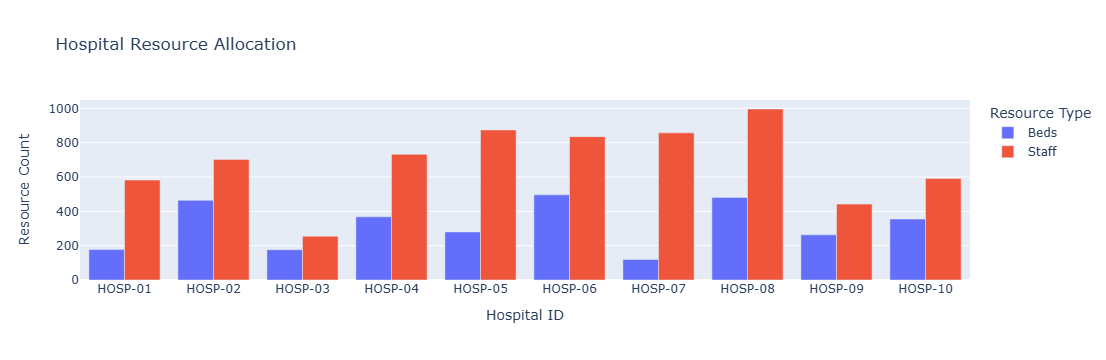

In [26]:
# Compare beds and staff across hospitals
resource_chart = px.bar(
    hospital_df,
    x="Hospital ID",
    y=["Beds", "Staff"],
    barmode="group",
    title="Hospital Resource Allocation",
    labels={"value": "Resource Count", "variable": "Resource Type"}
)

resource_chart.show()

### Patient Demographic Distribution

This visualization compares patient volume across age groups and gender to reveal demographic patterns in healthcare demand.

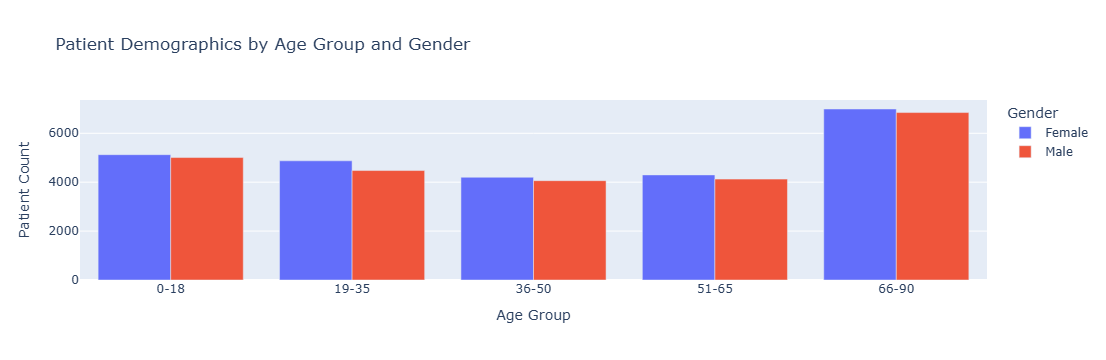

In [27]:
# Visualize patient distribution by age group and gender
demographic_chart = px.bar(
    demographic_analysis,
    x="Age Group",
    y="Patient Count",
    color="Gender",
    barmode="group",
    title="Patient Demographics by Age Group and Gender"
)

demographic_chart.show()

### Treatment Efficacy by Diagnosis

Treatment success rates are compared across diagnoses to identify conditions with relatively lower treatment effectiveness.

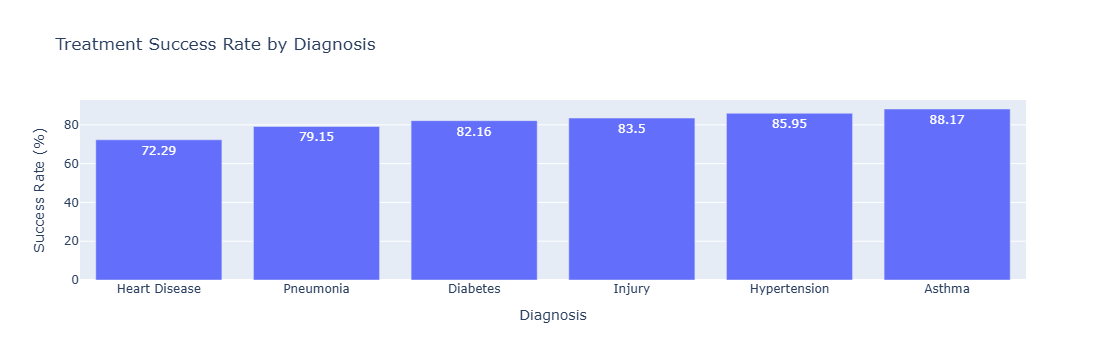

In [28]:
# Visualize treatment success rates by diagnosis
efficacy_chart = px.bar(
    diagnosis_efficacy,
    x="Diagnosis",
    y="Success Rate (%)",
    title="Treatment Success Rate by Diagnosis",
    text="Success Rate (%)"
)

efficacy_chart.show()

### Patient Density by ZIP Code

Patient volume is compared across residential ZIP codes to identify geographic concentrations of healthcare demand.

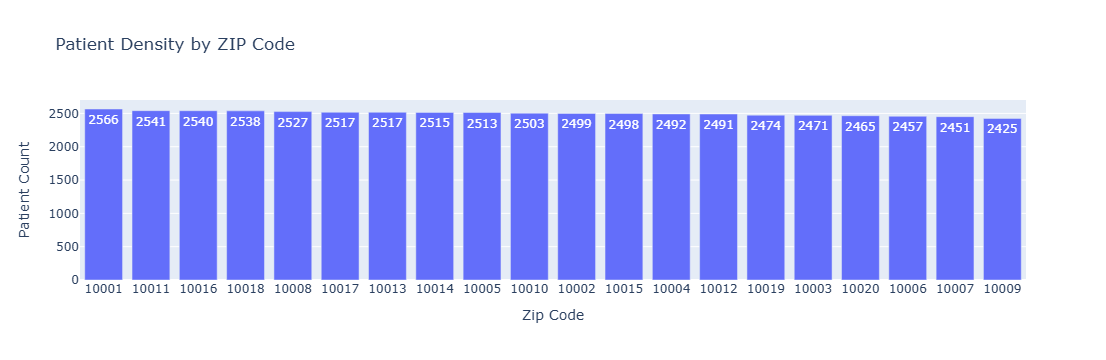

In [29]:
# Visualize patient demand by ZIP code
density_chart = px.bar(
    zip_demand,
    x="Zip Code",
    y="Patient Count",
    title="Patient Density by ZIP Code",
    text="Patient Count"
)

density_chart.update_xaxes(type="category")
density_chart.show()

### Geographic Patient Density Map

A fictional metropolitan coordinate grid is used to visualize patient demand geographically while preserving the synthetic nature of the dataset.

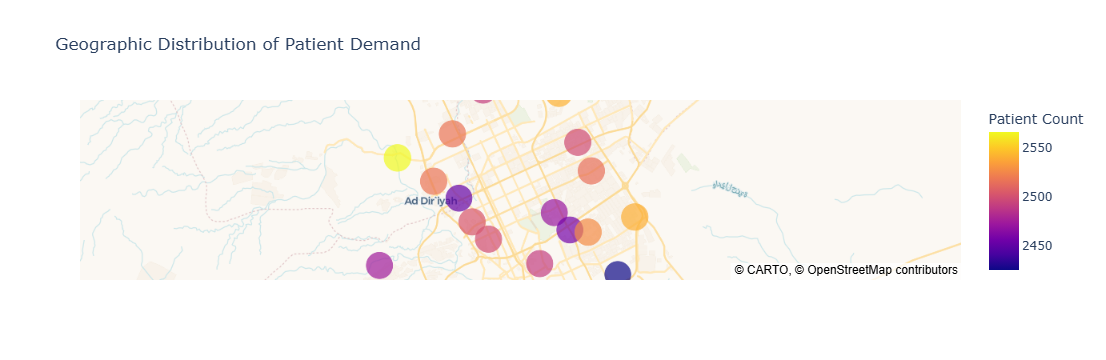

In [30]:
# Create fictional geographic coordinates for each ZIP code
zip_locations = pd.DataFrame({
    "Zip Code": zip_codes,
    "Latitude": np.random.uniform(24.60, 24.90, len(zip_codes)),
    "Longitude": np.random.uniform(46.50, 46.90, len(zip_codes))
})

# Add patient demand to each geographic location
map_data = zip_locations.merge(
    zip_demand,
    on="Zip Code",
    how="left"
)

# Create interactive patient-density map
density_map = px.scatter_map(
    map_data,
    lat="Latitude",
    lon="Longitude",
    size="Patient Count",
    color="Patient Count",
    hover_name="Zip Code",
    zoom=9,
    title="Geographic Distribution of Patient Demand"
)

density_map.show()

## 6. Interactive Healthcare Resource Dashboard

This dashboard integrates hospital resources, patient demographics, treatment efficacy, and geographic demand into one interactive decision-support interface.

In [31]:
# Import Dash components
from dash import Dash, dcc, html

# Create dashboard application
app = Dash(__name__)

app.layout = html.Div([
    html.H1("Healthcare Resource Allocation Dashboard"),

    html.H2("Hospital Resource Allocation"),
    dcc.Graph(figure=resource_chart),

    html.H2("Patient Demographics"),
    dcc.Graph(figure=demographic_chart),

    html.H2("Treatment Efficacy"),
    dcc.Graph(figure=efficacy_chart),

    html.H2("Geographic Patient Demand"),
    dcc.Graph(figure=density_map)
])

# Run dashboard
app.run(debug=False)

### Interactive Dashboard Filters

Dropdown filters allow users to explore healthcare data dynamically by hospital, diagnosis, and demographic group.

In [35]:
# Import callback tools
from dash import Input, Output

# Add interactive filters to the dashboard
app.layout = html.Div([
    html.H1("Healthcare Resource Allocation Dashboard"),

    html.H3("Interactive Filters"),

    html.Label("Hospital"),
    dcc.Dropdown(
        id="hospital-filter",
        options=[{"label": h, "value": h} for h in hospitals],
        value=hospitals[0],
        clearable=False
    ),

    html.Label("Diagnosis"),
    dcc.Dropdown(
        id="diagnosis-filter",
        options=[{"label": d, "value": d} for d in diagnoses],
        value=diagnoses[0],
        clearable=False
    ),

    html.Label("Gender"),
    dcc.Dropdown(
        id="gender-filter",
        options=[{"label": g, "value": g}
                 for g in patients_df["Gender"].unique()],
        value="Female",
        clearable=False
    ),

    dcc.Graph(id="filtered-chart")
])


# Update chart whenever a filter changes
@app.callback(
    Output("filtered-chart", "figure"),
    Input("hospital-filter", "value"),
    Input("diagnosis-filter", "value"),
    Input("gender-filter", "value")
)
def update_dashboard(hospital, diagnosis, gender):

    filtered_df = patients_df[
        (patients_df["Hospital ID"] == hospital) &
        (patients_df["Diagnosis"] == diagnosis) &
        (patients_df["Gender"] == gender)
    ]

    fig = px.histogram(
        filtered_df,
        x="Age",
        nbins=20,
        title=f"Patient Distribution: {hospital} | {diagnosis} | {gender}"
    )

    return fig


app.run(debug=False, port=8051)

## 7. Analytical Insights & Business Recommendations

### Key Findings

- Healthcare demand varies across ZIP codes, enabling identification of higher-demand geographic areas.
- Hospital resource capacity differs substantially across facilities when comparing beds, staff, and patient volumes.
- Patient-to-bed and patient-to-staff ratios reveal hospitals experiencing relatively greater resource pressure.
- Treatment efficacy varies by diagnosis, with Heart Disease showing the lowest success rate in the synthetic dataset.
- Demographic analysis shows differences in healthcare demand across age groups.

### Business Recommendations

1. Prioritize resource allocation toward hospitals with high patient-to-bed and patient-to-staff ratios.
2. Investigate lower treatment-success diagnoses to identify opportunities for clinical improvement.
3. Use ZIP-level demand patterns to guide staffing, capacity planning, and healthcare accessibility decisions.
4. Continuously monitor demographic demand to anticipate future resource requirements.

> **Note:** All patient and geographic data in this project are synthetic and intended solely for analytical demonstration.

In [36]:
# Export project datasets for documentation and reuse
patients_df.to_csv("healthcare_patients.csv", index=False)
hospital_df.to_csv("hospital_resources.csv", index=False)
department_df.to_csv("department_resources.csv", index=False)

print("Project datasets exported successfully!")

Project datasets exported successfully!
